In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
p = 80 # Precisão

a = 5 # Tamanho da fronteira em x
b = 5 # Tamanho da fronteira em y

V1 = lambda x: 3# Fronteira em x = 0
V2 = lambda y: 4 # Fronteira em y = 0
V3 = lambda x: 2 # Fronteira em x = a
V4 = lambda y: 1# Fronteira em y = b

In [9]:
def Laplace_Solver(p, V1, V2, V3, V4):
  P = np.zeros((p**2, p**2))
  K = np.zeros(p**2)
  P += np.diag(4*np.ones(p**2))

  for i in range(p):
    for j in range(p):
      aux = j*p + i

      if  i > 0:
        P[aux, aux-1] = -1
      else:
        K[aux] += V2(j)

      if  j > 0:
        P[aux, aux-p] = -1
      else:
        K[aux] += V1(i)

      if  i < p-1:
        P[aux, aux+1] = -1
      else:
        K[aux] += V4(j)

      if  j < p-1:
        P[aux, aux+p] = -1
      else:
        K[aux] += V3(i)

  P_inv = np.linalg.inv(P)
  V = np.dot(K, P_inv)
  V = V.reshape(p, p)
  V_t = np.zeros((p+2, p+2))
  V_t[1:-1, 1:-1] = V
  V_t[0, 1:-1] = V1(np.linspace(0, a, p+2)[1:-1])
  V_t[-1, 1:-1] = V3(np.linspace(0, a, p+2)[1:-1])
  V_t[1:-1, 0] = V2(np.linspace(0, b, p+2)[1:-1])
  V_t[1:-1, -1] = V4(np.linspace(0, b, p+2)[1:-1])

  return V_t

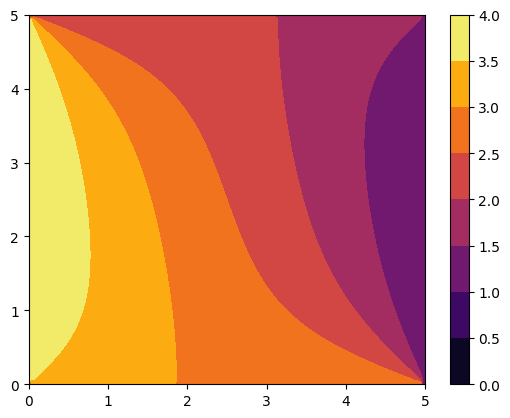

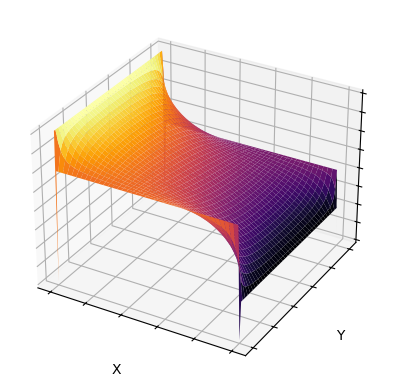

In [10]:
# Plot 1:



x = np.linspace(0, a, p+2)
y = np.linspace(0, b, p+2)

X, Y = np.meshgrid(x, y)

Z = Laplace_Solver(p, V1, V2, V3, V4)

fig, ax = plt.subplots()
CS = ax.contourf(X, Y, Z, cmap="inferno")
plt.colorbar(CS)

plt.show()

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, cmap="inferno")

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U')

plt.show()

In [11]:
def Laplace_Solver_e(p, V1, V2, V3, V4):
  P = np.zeros((p**2, p**2)) # Matriz dos coeficientes
  K = np.zeros(p**2) # Matriz com as condições de fronteira

  P += np.diag(4*np.ones(p**2))
  P -= np.diag(np.ones(p**2-p), p) 
  P -= np.diag(np.ones(p**2-p), -p)
  P -= np.kron(np.eye(p), np.diag(np.ones(p-1), 1))
  P -= np.kron(np.eye(p), np.diag(np.ones(p-1), -1))

  for i in range(p):
    for j in range(p):
      aux = j*p + i
      if i == 0:
        K[aux] += V2(j)
      elif i == p-1:
        K[aux] += V4(j)
      if j == 0:
        K[aux] += V1(i)
      elif j == p-1:
        K[aux] += V3(i)

  # Resolvendo o sistema linear
  V = np.linalg.solve(P, K)

  V_t = np.zeros((p+2, p+2))
  V_t[1:-1, 1:-1] = V.reshape((p, p))
  V_t[0, 1:-1] = V1(np.linspace(0, a, p+2)[1:-1])
  V_t[-1, 1:-1] = V3(np.linspace(0, a, p+2)[1:-1])
  V_t[1:-1, 0] = V2(np.linspace(0, b, p+2)[1:-1])
  V_t[1:-1, -1] = V4(np.linspace(0, b, p+2)[1:-1])

  return V_t


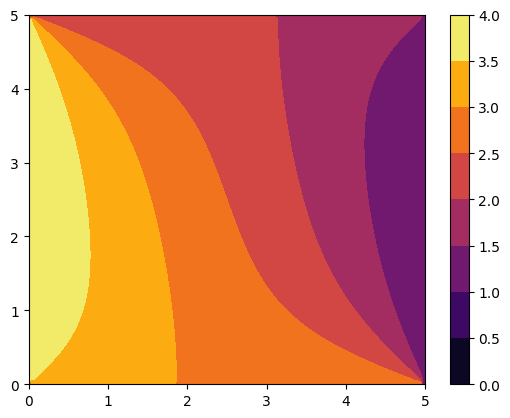

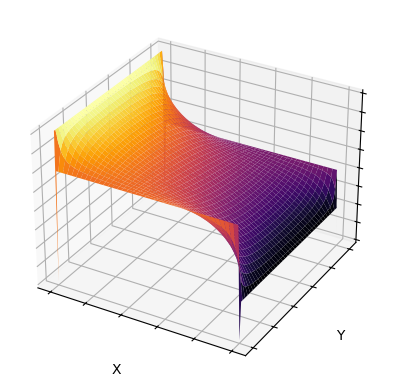

In [12]:
# Plot 2:

x = np.linspace(0, a, p+2)
y = np.linspace(0, b, p+2)

X, Y = np.meshgrid(x, y)

Z = Laplace_Solver_e(p, V1, V2, V3, V4)

fig, ax = plt.subplots()
CS = ax.contourf(X, Y, Z, cmap="inferno")
plt.colorbar(CS)
plt.show()

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, cmap="inferno")

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U')

plt.show()